In [1]:
import dask.dataframe as dd
import pandas as pd
import numpy as np
from astropy.table import Table
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.stats import gaussian_kde
from odrpack import odr_fit
roots_tfm = '/home/julien/Documents/Etudes/Astrofisica/Master/TFM/Data'

In [2]:
#df = dd.read_csv(roots_tfm + '/Galex/GUVCat_AIS_FOV055_glat50_00N__55_00N.csv', \
#                 names=['objid','ra','dec','tilenum','nuv_flux','nuv_fluxerr', \
#                         'fuv_flux','fuv_fluxerr','nuv_poserr'],header=0)
#df = pd.read_csv(roots_tfm + '/Galex/GUVCat_AIS_FOV055_glat50_00N__55_00N_lite.csv')
#df = pd.read_csv(roots_tfm + '/Galex/GUVCat_AIS_FOV055_glat05_00N__10_00N_lite.csv')
df = pd.read_csv(roots_tfm + '/Galex/match_Galex_UVOT_OM_best.csv')
df_all = pd.read_csv(roots_tfm + '/Galex/match_Galex_UVOT_OM_all.csv')

In [3]:
#df_nuvposerr_zero = pd.read_csv(roots_tfm + '/Galex/match_Galex_UVOT_OM_best_nuvposerr_zero.csv')
#df_nuvposerr_27 = pd.read_csv(roots_tfm + '/Galex/match_Galex_UVOT_OM_best_nuvposerr_27.csv')
#df_nuvposerr=pd.read_csv(roots_tfm + '/Galex/match_Galex_UVOT_OM_best_maxReal_nuvposerr.csv')
#df_nuvposerr_zero[~df_nuvposerr_zero['objid'].isin(df_nuvposerr_27['objid'])]
#df_nuvposerr = df_nuvposerr.rename(columns={'ra_1':'RA','dec_1':'DEC','nuv_poserr':'POSERR','objid':'SRCNUM',\
#                       'nuv_flux':'NUV_FLUX', 'nuv_fluxerr' : 'NUV_FLUX_ERR', \
#                         'fuv_flux': 'FUV_FLUX','fuv_fluxerr' : 'FUV_FLUX_ERR'})

In [4]:
df[df['objid'] == 6378761888717607197]

,objid,ra_1,dec_1,fuv_flux,fuv_fluxerr,nuv_flux,nuv_fluxerr,nuv_poserr,SRCNUM_CUV,SRCNUM_OM,SRCNUM_UVOT,RA_2,DEC_2,POSERR,COUNT,angDist,MAX_POSERR
233754,6378761888717607197,192.0634,17.773017,-999.0,-999.0,92.197701,5.092167,0.538217,455440,3298282,0,192.063446,17.774125,0.549904,13,3.99236,2.7


In [5]:
df=df.replace(-999,np.nan)

In [6]:
df.shape

(245622, 17)

In [7]:
df_all.shape

(265960, 17)

In [8]:
df_merge = df_all[df_all.duplicated(subset=['objid'])].merge(df,on='objid')
df['SUSPICIOUS_MATCH'] = False
df.loc[df['objid'].isin(df_merge['objid']),'SUSPICIOUS_MATCH'] = True

In [9]:
df[df['SRCNUM_CUV'].isin([17140,181611,23279,23952,118973,140644,231964,241569,304348,192147,199154,447527,452540])][['SRCNUM_CUV','angDist','SUSPICIOUS_MATCH']]

,SRCNUM_CUV,angDist,SUSPICIOUS_MATCH
9234,241569,0.730161,False
37399,231964,0.164711,True
79815,140644,1.390323,False
118011,118973,0.756137,False
120591,452540,1.995175,False
125735,192147,0.368718,True
128690,199154,0.953263,False
132387,17140,1.366948,False
153807,23952,0.634129,False
202794,447527,0.349616,True


In [10]:
df.dtypes

objid                 int64
ra_1                float64
dec_1               float64
fuv_flux            float64
fuv_fluxerr         float64
nuv_flux            float64
nuv_fluxerr         float64
nuv_poserr          float64
SRCNUM_CUV            int64
SRCNUM_OM             int64
SRCNUM_UVOT           int64
RA_2                float64
DEC_2               float64
POSERR              float64
COUNT                 int64
angDist             float64
MAX_POSERR          float64
SUSPICIOUS_MATCH       bool
dtype: object

In [11]:
df = df.rename(columns={'ra_1':'RA','dec_1':'DEC','nuv_poserr':'POSERR','objid':'SRCNUM',\
                       'nuv_flux':'NUV_FLUX', 'nuv_fluxerr' : 'NUV_FLUX_ERR', \
                         'fuv_flux': 'FUV_FLUX','fuv_fluxerr' : 'FUV_FLUX_ERR','POSERR' : 'POSERR_UVOT_OM'})

In [12]:
df.head()

,SRCNUM,RA,DEC,FUV_FLUX,FUV_FLUX_ERR,NUV_FLUX,NUV_FLUX_ERR,POSERR,SRCNUM_CUV,SRCNUM_OM,SRCNUM_UVOT,RA_2,DEC_2,POSERR_UVOT_OM,COUNT,angDist,MAX_POSERR,SUSPICIOUS_MATCH
0,6373097221993268460,83.884105,40.187670,27.279566,3.999979,29.566187,4.045698,0.625514,67130,0,1014525,83.883805,40.187728,0.358525,3,0.852187,2.7,False
1,6371795405592593744,330.548352,66.793384,NaN,NaN,10.336556,2.764180,1.608465,259861,0,5880541,330.547788,66.793715,0.184504,3,1.434355,2.7,False
2,6372921272213439560,75.695632,51.364949,NaN,NaN,3.943771,1.769961,1.987474,366626,1277019,0,75.698745,51.366267,0.541615,1,8.452921,2.7,False
3,6373976851694487732,100.268286,26.473098,NaN,NaN,3.807085,1.412635,1.266602,78042,0,1320921,100.267939,26.473093,0.611849,1,1.119616,2.7,False
4,6373976851696585056,100.261757,26.502480,3.971011,1.676836,6.980900,1.855379,1.075492,78038,0,1320711,100.262181,26.502354,0.489386,4,1.438630,2.7,False


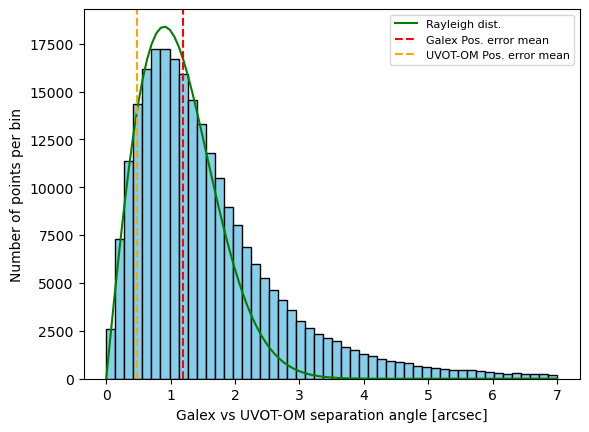

In [13]:
from scipy.stats import rayleigh
# Plot figure
fig, ax =plt.subplots()
#(n,bins,patches) = ax.hist(df_nuvposerr[df_nuvposerr['angDist']<7]['angDist'], bins=50, color='magenta',edgecolor='black', label='max(2.7,3*POSERR)')
#(n,bins,patches) = ax.hist(df[df['angDist']<7]['angDist'], bins=50, color='skyblue',edgecolor='black', label='3*POSERR')
(n,bins,patches) = ax.hist(df[df['angDist']<7]['angDist'], bins=50, color='skyblue',edgecolor='black')
x = np.linspace(0,7,100)
ax.plot(x,df.shape[0]*rayleigh.pdf(x,0,0.9)/9,color='green', linestyle='solid',label="Rayleigh dist.")
ax.axvline(np.mean(df['POSERR']), linestyle='dashed', color='r',label='Galex Pos. error mean')
ax.axvline(np.mean(df['POSERR_UVOT_OM']), linestyle='dashed', color='orange',label='UVOT-OM Pos. error mean')
ax.set_xlabel("Galex vs UVOT-OM separation angle [arcsec]")
ax.set_ylabel("Number of points per bin")
ax.legend(prop={'size': 8})
fig.savefig(roots_tfm + '/Galex/match_Galex_UVOT_OM.png',dpi=1200)  

In [14]:
filepath_count = roots_tfm + '/Galex/count_random_match.txt'
df_count = pd.read_csv(filepath_count,sep=' ',skiprows=[0],header=None,usecols=[5])
sum = 0
i=0
while sum<(df.shape[0] - df_count[5].sum()):
    sum = sum + n[i]
    i=i+1
print("Sum of cumulated matchs until bin number " + str(i) + " : " + str(sum))
print("Corresponding maximum angle : {:.2E}".format(bins[i]))

Sum of cumulated matchs until bin number 30 : 234301.0
Corresponding maximum angle : 4.20E+00


In [15]:
df = df[df['angDist']<4]
df.shape

(232555, 18)

In [16]:
df = df.astype({'SRCNUM': np.int64, 'NUV_FLUX': np.float32, 'FUV_FLUX': np.float32, \
                'NUV_FLUX_ERR': np.float32, 'FUV_FLUX_ERR': np.float32, 'RA': np.float64, \
                'DEC': np.float64, 'POSERR': np.float32})

In [17]:
df_radec = df[['RA','DEC','POSERR','SRCNUM']]
df_radec.shape

(232555, 4)

In [43]:
df_entries = df[['SRCNUM','NUV_FLUX','NUV_FLUX_ERR','FUV_FLUX','FUV_FLUX_ERR','SRCNUM_OM','SRCNUM_CUV']]
df_entries =df_entries.rename(columns={'SRCNUM': 'SRCNUM_GALEX'})
df_entries_cor = df_entries[['SRCNUM_CUV','SRCNUM_GALEX','SRCNUM_OM']].copy()
df_entries_cor['NUV_UVW2_FLUX'] = np.nan
df_entries_cor['NUV_UVW2_FLUX_ERR'] = np.nan
df_entries_cor['FUV_UVW2_FLUX'] = np.nan
df_entries_cor['FUV_UVW2_FLUX_ERR'] = np.nan
df_entries_cor['NUV_UVM2_FLUX'] = np.nan
df_entries_cor['NUV_UVM2_FLUX_ERR'] = np.nan
df_entries_cor['FUV_UVM2_FLUX'] = np.nan
df_entries_cor['FUV_UVM2_FLUX_ERR'] = np.nan
df_entries_cor['NUV_UVW1_FLUX'] = np.nan
df_entries_cor['NUV_UVW1_FLUX_ERR'] = np.nan
df_entries_cor['FUV_UVW1_FLUX'] = np.nan
df_entries_cor['FUV_UVW1_FLUX_ERR'] = np.nan

In [19]:
dat_OM=pd.read_csv(roots_tfm + '/XMM-Newton/Entries_OM_galaxies.csv')

In [20]:
def f(x: np.ndarray, beta: np.ndarray) -> np.ndarray:
    b0, b1, b2 = beta
    return b0+ b1*x+ b2*x**2  

In [21]:
beta0 = [-16.0, 0.2, 0.1]
lower = [-30.0, 0.0, 0.0]
upper = [0.0, 1.0, 0.3]

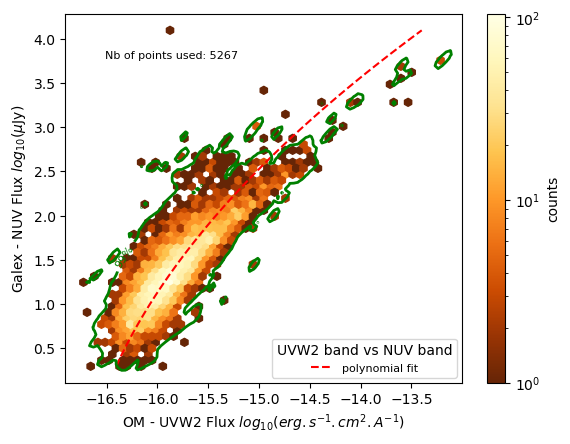

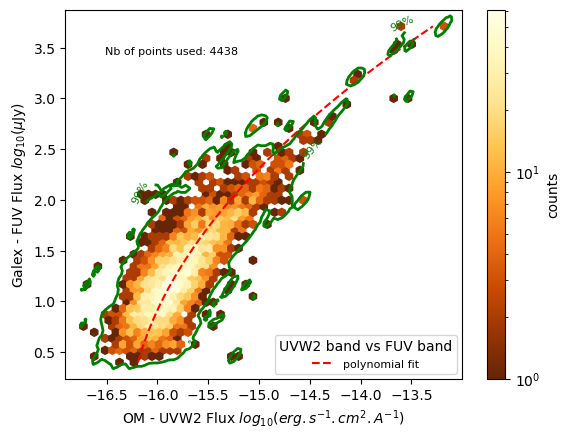

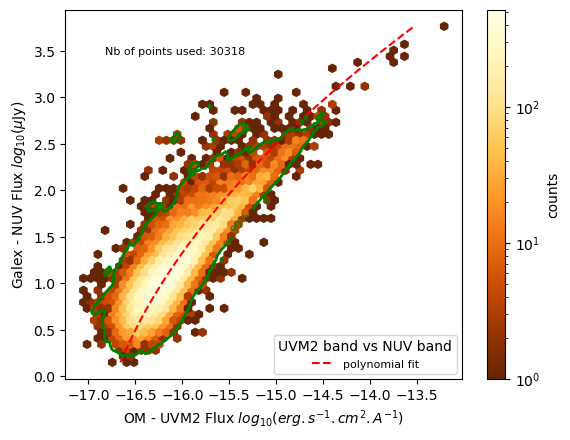

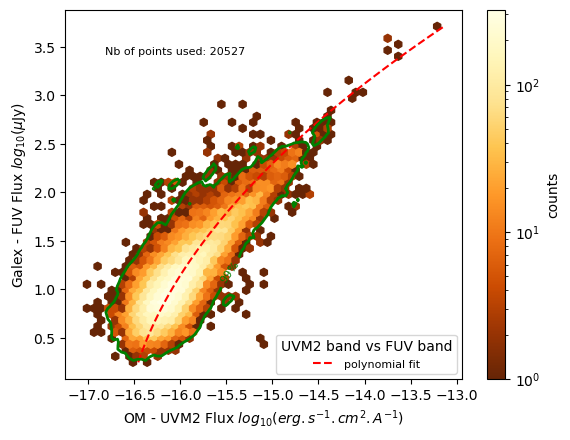

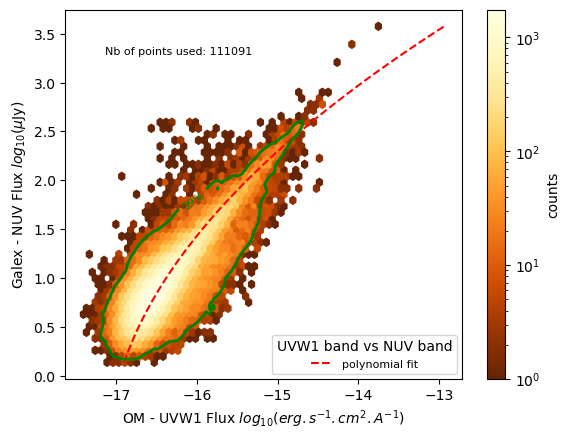

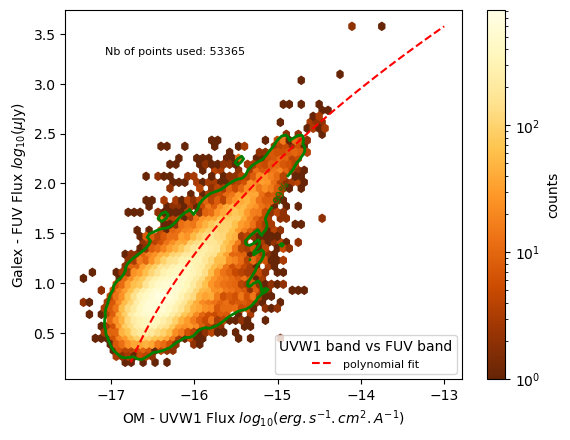

In [44]:
for flux in ['UVW2','UVM2','UVW1']: 
  
    flux_name = flux + '_FLUX'
    flux_err = flux + '_FLUX_ERR'
    flag_extended = flux + '_EXTENDED'
    flux_quality = flux + '_QUALITY_FLAG'

    # Dataframe OM for this band
    df_flux_om = dat_OM[['SRCNUM',flux_name,flux_err,flag_extended, flux_quality]].dropna(subset=[flux_name]).reset_index()  
    df_flux_om = df_flux_om[df_flux_om[flux_quality] == 0]

    for flux_galex in ['NUV','FUV']:
        
        flux_galex_name = flux_galex + '_FLUX'
        flux_galex_err = flux_galex + '_FLUX_ERR'

         # Data frame Galex for this band
        df_flux_galex = df_entries[[flux_galex_name,flux_galex_err,'SRCNUM_OM']].dropna(subset=[flux_galex_name])
        df_flux_galex = df_flux_galex[df_flux_galex['SRCNUM_OM'] != 0]
        df_flux_galex=df_flux_galex.reset_index()

        # Merge with UVOT results
        df_merge = df_flux_galex.merge(df_flux_om, left_on='SRCNUM_OM', right_on='SRCNUM')

        # Plot figure
        fig, ax =plt.subplots()
        x=np.log10(df_merge[flux_name])
        y=np.log10(df_merge[flux_galex_name])
        hb =ax.hexbin(x,y,gridsize=50, bins='log', cmap='YlOrBr_r')
        cb = fig.colorbar(hb, ax=ax, label='counts')
        
        x=np.log10(df_merge.loc[:,flux_name])
        y=np.log10(df_merge.loc[:,flux_galex_name]) 
        weight_x = 1/np.log10(df_merge.loc[:,flux_err])**2
        weight_y = 1/np.log10(df_merge.loc[:,flux_galex_err])**2
        #p = np.poly1d(np.polyfit(y,x, deg=2))
        sol = odr_fit(f, y, x, beta0, bounds=(lower, upper), weight_x=weight_y, weight_y=weight_x)
        yp = np.linspace(y.min(), y.max(), 100)
        #ax.plot(p(yp), yp, color='b', linestyle='dashed', label= "log(Galex)") 
        ax.plot(f(yp,sol.beta), yp, color='r', linestyle='dashed', label= "polynomial fit")

        xmin, xmax= ax.get_xlim()
        ymin, ymax= ax.get_ylim()
        
        random_row_index = np.random.default_rng().choice(df_merge.index.values,100000)
        data = np.vstack([np.log10(df_merge.loc[random_row_index,flux_name]),np.log10(df_merge.loc[random_row_index,flux_galex_name])])
        kde = gaussian_kde(data)
        grid_x, grid_y = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
        grid_coords = np.vstack([grid_x.ravel(), grid_y.ravel()])
        z = kde(grid_coords).reshape(100, 100)
        thresholds=np.percentile(kde.evaluate(kde.resample(40000)),1)
        contour = ax.contour(grid_x,grid_y,z,levels=[thresholds],colors='green',linewidths=2)
        ax.clabel(contour, inline=True, fontsize=8, fmt={thresholds: f"{99}%"})

        df_entries_cor.loc[:,flux_galex + '_' + flux_name] = 10**f(np.log10(df_entries.loc[:,flux_galex_name]),sol.beta)
        df_entries_cor.loc[:,flux_galex + '_' + flux_err] = 10**f(np.log10(df_entries.loc[:,flux_galex_name] + df_entries.loc[:,flux_galex_err]),sol.beta) - \
                                                                 10**f(np.log10(df_entries.loc[:,flux_galex_name]),sol.beta)
        
        ax.set_xlabel("OM - " + flux + ' Flux ' +"$log_{10}(erg.s^{-1}.cm^{2}.A^{-1})$")
        ax.set_ylabel("Galex - " + flux_galex + ' Flux '  +"$log_{10}(\mu$" +"Jy)")
        ax.legend(loc='lower right',prop={'size': 8},title= flux + " band vs " + flux_galex + " band")
        ax.text(0.1, 0.9, 'Nb of points used: ' + str(x.shape[0]), dict(size=8), transform=ax.transAxes, va='top')
        fig.savefig(roots_tfm + '/Calibration/OM_' + flux + '_vs_Galex_ ' + flux_galex + "_galaxies.png",dpi=1200)  

In [23]:
df_merge.head()

,index_x,FUV_FLUX,FUV_FLUX_ERR,SRCNUM_OM,index_y,SRCNUM,UVW1_FLUX,UVW1_FLUX_ERR,UVW1_EXTENDED,UVW1_QUALITY_FLAG
0,40,13.727663,5.544144,2843657,185222,2843657,2.088716e-16,1.445731e-17,False,0
1,160,12.341626,3.522213,2279301,135187,2279301,6.364551e-17,7.554140e-18,False,0
2,194,153.614853,15.177100,5532752,377042,5532752,8.286474e-16,1.446986e-17,True,0
3,196,24.444431,5.550780,5527551,377000,5527551,2.258346e-16,8.739834e-18,True,0
4,291,32.266911,6.376765,3102952,217352,3102952,1.310206e-16,5.548749e-18,True,0


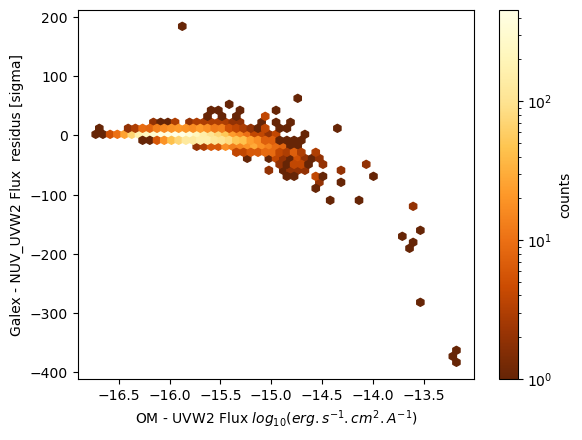

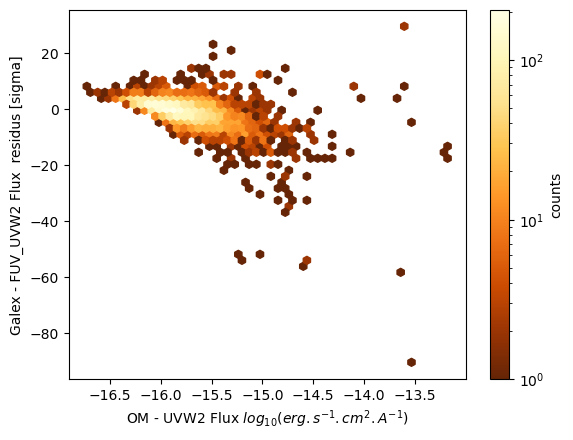

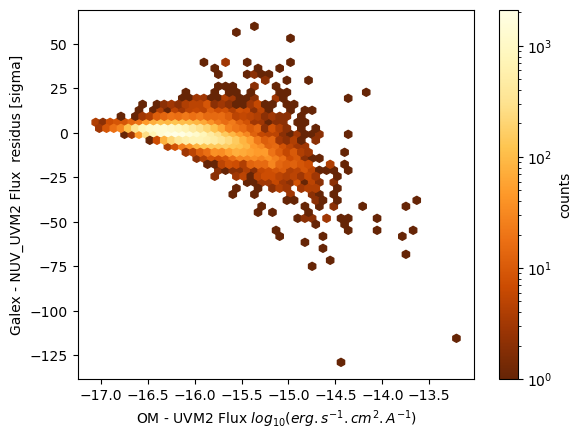

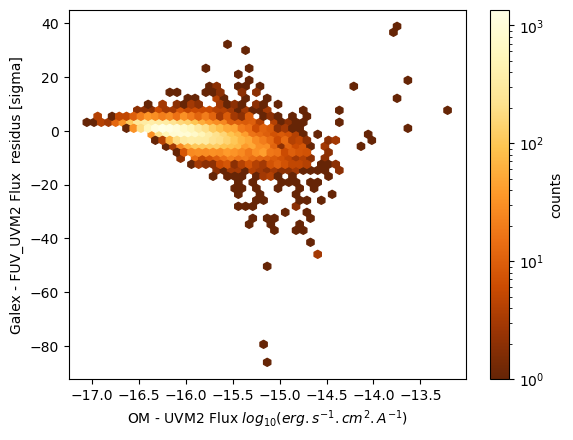

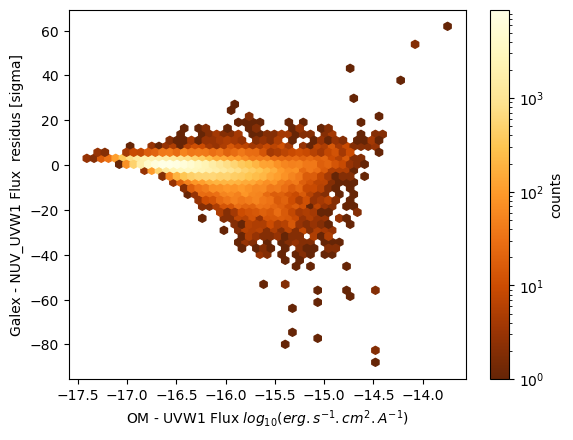

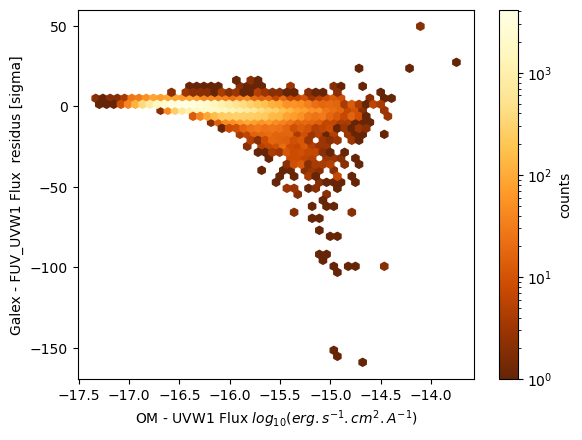

In [45]:
for flux in ['UVW2','UVM2','UVW1']: 
  
    flux_name = flux + '_FLUX'
    flux_err = flux + '_FLUX_ERR'
    flag_extended = flux + '_EXTENDED'
    flux_quality = flux + '_QUALITY_FLAG'

    # Dataframe OM for this band
    df_flux_om = dat_OM[['SRCNUM',flux_name,flux_err,flag_extended, flux_quality]].dropna(subset=[flux_name]).reset_index()  
    df_flux_om = df_flux_om[df_flux_om[flux_quality] == 0]

    for flux_galex in ['NUV','FUV']:
        
        flux_galex_name = flux_galex + '_' + flux + '_FLUX'
        flux_galex_err = flux_galex + '_' + flux_err

         # Data frame Galex for this band
        df_flux_galex = df_entries_cor[[flux_galex_name,flux_galex_err,'SRCNUM_OM']].dropna(subset=[flux_galex_name])
        df_flux_galex = df_flux_galex[df_flux_galex['SRCNUM_OM'] != 0]
        df_flux_galex=df_flux_galex.reset_index()

        # Merge with UVOT results
        df_merge = df_flux_galex.merge(df_flux_om, left_on='SRCNUM_OM', right_on='SRCNUM')

        # Plot figure
        fig, ax =plt.subplots()
        x=np.log10(df_merge[flux_name])
        y=(df_merge[flux_galex_name]-df_merge[flux_name])/df_merge[flux_galex_err]
        hb =ax.hexbin(x,y,gridsize=50, bins='log', cmap='YlOrBr_r')
        cb = fig.colorbar(hb, ax=ax, label='counts')
        #xmin, xmax= ax.get_xlim()
        #ax.plot([xmin, xmax],[xmin, xmax], color='black', linestyle='dashed', label="y=x")         
        ax.set_xlabel("OM - " + flux + ' Flux ' +"$log_{10}(erg.s^{-1}.cm^{2}.A^{-1})$")
        ax.set_ylabel("Galex - " + flux_galex + '_' + flux + " Flux  residus [sigma]")
        #ax.legend(loc='upper right',prop={'size': 8},title= flux + " band vs " + flux_galex + " band")
        fig.savefig(roots_tfm + '/Calibration/OM_' + flux + '_vs_Galex_ ' + flux_galex + "_galaxies_residus.png",dpi=1200) 

In [39]:
df_entries_cor = df_entries_cor.drop({'SRCNUM_OM'},axis=1)

In [37]:
df_entries_cor.head()

,SRCNUM_CUV,SRCNUM_GALEX,SRCNUM_OM,NUV_UVW2_FLUX,NUV_UVW2_FLUX_ERR,FUV_UVW2_FLUX,FUV_UVW2_FLUX_ERR,NUV_UVM2_FLUX,NUV_UVM2_FLUX_ERR,FUV_UVM2_FLUX,FUV_UVM2_FLUX_ERR,NUV_UVW1_FLUX,NUV_UVW1_FLUX_ERR,FUV_UVW1_FLUX,FUV_UVW1_FLUX_ERR
0,67130,6373097221993268460,0,1.611494e-16,1.397367e-17,1.961965e-16,1.865107e-17,1.276383e-16,1.290468e-17,1.612782e-16,1.815795e-17,1.092390e-16,1.497690e-17,1.376317e-16,1.941079e-17
1,259861,6371795405592593744,0,8.616509e-17,1.221356e-17,NaN,NaN,6.203638e-17,1.019447e-17,NaN,NaN,4.274977e-17,9.137543e-18,NaN,NaN
3,78042,6373976851694487732,0,5.207703e-17,8.395354e-18,NaN,NaN,3.495064e-17,6.455930e-18,NaN,NaN,2.118176e-17,4.739393e-18,NaN,NaN
4,78038,6373976851696585056,0,6.994844e-17,9.198765e-18,7.457592e-17,1.063705e-17,4.887330e-17,7.410989e-18,4.859463e-17,9.409921e-18,3.173408e-17,6.088006e-18,2.928069e-17,7.926690e-18
5,78117,6373976851696586502,0,1.473018e-16,1.562094e-17,1.144831e-16,2.025657e-17,1.150368e-16,1.422927e-17,8.431285e-17,1.862795e-17,9.516505e-17,1.593258e-17,6.073748e-17,1.765763e-17


In [40]:
db_path ='sqlite:///'+ roots_tfm + '/UVCatalogue.db'
df_entries_cor.to_sql("Entries_GALEX", db_path, if_exists='replace', index=False, chunksize=1000, method="multi")

232555

In [41]:
df_entries_cor.to_csv(roots_tfm+'/Galex/Entries_Galex_Galaxies.csv',index=False)